In [ ]:
%matplotlib notebook
from battle_factory import ClassifierTrainer
from model import AEViT
from dataset import PowderDataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Optional, Union
import torchvision.transforms as t
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm

In [2]:
pt_vibrant = {
    "blue" : "#0077BB",
    "cyan" : "#33BBEE",
    "teal" : "#009988",
    "orange" : "#EE7733",
    "red" : "#CC3311",
    "magenta" : "#EE3377",
    "grey" : "#BBBBBB"
}

In [3]:
transforms = [t.RandomErasing(), t.RandomAdjustSharpness(0.5), t.RandomAffine(45), t.RandomAutocontrast(), t.RandomHorizontalFlip(), t.RandomVerticalFlip()]

In [6]:
class AEViTrainer(ClassifierTrainer):
    def load_data(self) -> None:
        """
        This class method loads the training and validation data. This depends on the format of the data.
        """

        f = np.load(self.data_pth)

        self.train_in = f["train_in"]/255
        self.train_out = f["train_out"]
        self.val_in = f["val_in"]/255
        self.val_out = f["val_out"]
    
    def train(self, train_loader: DataLoader) -> float:
        """
        This class method performs the training step for one epoch given the training data loader.
        """

        self.model.vit.train()
        batch_losses = []
        for j, (images, labels) in enumerate(tqdm(train_loader)):
            images, labels = images.float().to(self.device), labels.long().to(self.device)

            self.optimiser.zero_grad()
            output = self.model(images)
            loss = self.loss_fn(output, labels)
            loss.backward()
            self.optimiser.step()

            batch_losses.append(loss.item())

        if self.scheduler and (self.current_epoch >= 5):
            self.scheduler.step()

        return torch.mean(torch.tensor(batch_losses))
    
    def validation(self, val_loader: torch.utils.data.DataLoader) -> float:
        self.model.vit.eval()

        total, correct = 0., 0.
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.float().to(self.device), labels.long().to(self.device)
                output = self.model(images)
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum()

        return float((correct / total) * 100)
    
    def cool_beauty(self, load: bool = False, load_pth: Optional[str] = None, transform: Union[nn.Module, nn.Sequential, t.Compose, None] = None) -> None:
        """
        This class method trains the network with the interactive plotting environment.
        """
    
        if load:
            print("=> a model is being loaded.")
            self.load_checkpoint(load_pth)

        # dataset and data loader creation
        train_dataset = PowderDataset(torch.from_numpy(self.train_in), torch.from_numpy(self.train_out), transform=transform)
        val_dataset = PowderDataset(torch.from_numpy(self.val_in), torch.from_numpy(self.val_out), transform=transform)
        # val_dataset = PowderDataset(torch.from_numpy(self.val_in), torch.from_numpy(self.val_out))

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=True)

        #initialisation of the plotting environment
        fig = plt.figure(figsize=(6,6))
        train_ax = fig.add_subplot(1,1,1)
        val_ax = train_ax.twinx()
        # train_ax.set_yscale("log")
        train_ax.set_ylabel("Training Loss", color=pt_vibrant["cyan"])
        train_ax.set_xlabel("Number of Epochs")
        val_ax.set_ylabel("Validation Classification [%]", color=pt_vibrant["magenta"])
        fig.show()
        fig.canvas.draw()

        #define lists to store the different losses in
        train_losses, val_losses = [], []

        #do the training and validation
        t_init = time()
        for n in range(self.total_epochs):
            if n != 0:
                self.current_epoch += 1
            if n == 0 and load:
                self.current_epoch += 1

            tl = self.train(train_loader=train_loader)
            train_losses.append(tl.item())

            vl = self.validation(val_loader=val_loader)
            val_losses.append(vl)
            t_now = round(time() - t_init, 3)

        #save the model
            self.train_losses = train_losses
            self.val_losses = val_losses

#             if self.scheduler:
#                 self.checkpoint(add_info={"scheduler_state_dict" : self.scheduler.state_dict()})
#             else:
#                 self.checkpoint()
#             self.save_checkpoint()

        #plot the results
            fig.suptitle(f"Time elapsed {t_now}s after epoch {self.current_epoch}")
            train_ax.set_ylabel("Training Loss", color=pt_vibrant["cyan"])
            train_ax.set_xlabel("Number of Epochs")
            val_ax.set_ylabel("Validation Classification [%]", color=pt_vibrant["magenta"])
            train_ax.semilogy(train_losses, color=pt_vibrant["cyan"], marker="o")
            val_ax.plot(val_losses, color=pt_vibrant["magenta"], marker="o")
            fig.canvas.draw()

In [7]:
aevit = AEViT(1,64,"199_no_scheduler_1e-2.pth",6*256,256,3,1024,6,16,2048,6,4)
optimi = optim.Adam(filter(lambda p: p.requires_grad, aevit.parameters()), lr=1e-2, weight_decay=1e-6)
# sched = optim.lr_scheduler.StepLR(optimi, 50)
# sched = optim.lr_scheduler.CosineAnnealingLR(optimi, T_max=50, eta_min=1e-7)
loss_fn = nn.CrossEntropyLoss()

In [8]:
trainer = AEViTrainer(aevit, optimi, loss_fn, 3000, 4, "training_data_15.npz", scheduler=sched)

In [9]:
%%time
trainer.load_data()

CPU times: total: 13.3 s
Wall time: 1min 38s


<IPython.core.display.Javascript object>


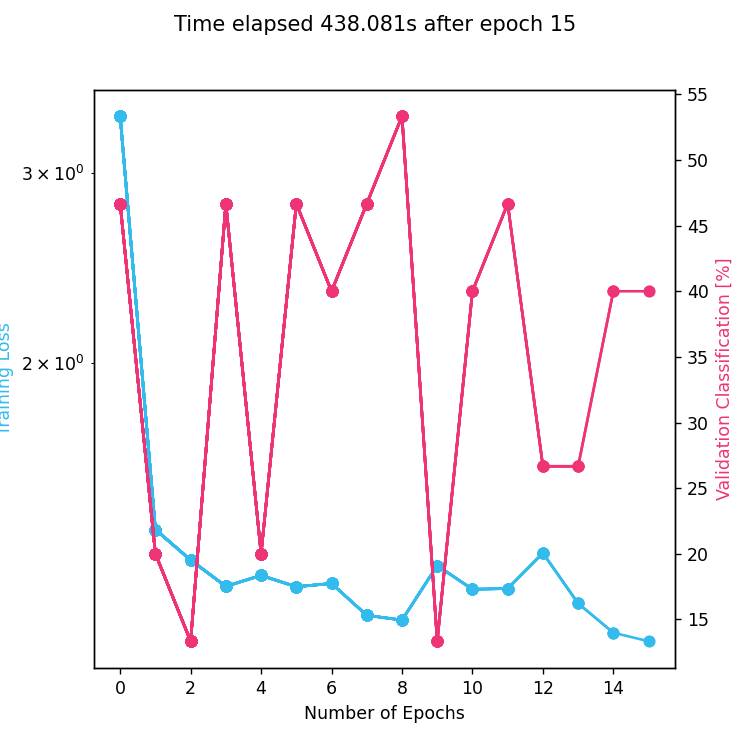

 14%|███████████▊                                                                       | 3/21 [00:03<00:21,  1.19s/it]


KeyboardInterrupt: 

In [10]:
trainer.cool_beauty(transform=transforms)